In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#load data from csv file
csv =pd.read_csv('CA2_Even.csv')
#shape of the data set
print("shape of the data set :" ,csv.shape)
#columns of the data set
print(csv.columns)

shape of the data set : (503, 15)
Index(['Record_ID', 'Pandemic', 'Country', 'Continent', 'Year',
       'Population_Hundreds', 'Total_Cases_Hundreds', 'Total_Deaths_Hundreds',
       'Recovered_Hundreds', 'Vaccinated_Hundreds', 'Hospital_Beds_Hundreds',
       'Tests_Hundreds', 'Healthcare_Workers_Hundreds',
       'Peak_Daily_Cases_Hundreds', 'Vaccination_Rate'],
      dtype='str')


data preprocssing

In [26]:
before_cleaning = csv.copy()
# Display the dataset before cleaning
print("DATASET BEFORE CLEANING")
print("-----------------------")

print("Shape:", before_cleaning.shape)

print("\nMissing values before cleaning:")
print(before_cleaning.isnull().sum())

print("\nTotal missing values before cleaning:")
print(before_cleaning.isnull().sum().sum())

print("\nDuplicate rows before cleaning:")
print(before_cleaning.duplicated().sum())




DATASET BEFORE CLEANING
-----------------------
Shape: (503, 15)

Missing values before cleaning:
Record_ID                      0
Pandemic                       0
Country                        0
Continent                      0
Year                           0
Population_Hundreds            0
Total_Cases_Hundreds           3
Total_Deaths_Hundreds          0
Recovered_Hundreds             0
Vaccinated_Hundreds            2
Hospital_Beds_Hundreds         0
Tests_Hundreds                 0
Healthcare_Workers_Hundreds    0
Peak_Daily_Cases_Hundreds      0
Vaccination_Rate               1
dtype: int64

Total missing values before cleaning:
6

Duplicate rows before cleaning:
3


In [27]:
# cleanning dataset

print("UNIQUE COUNTRY VALUES")
print("---------------------")
print(csv["Country"].unique())
print("\nUNIQUE PANDEMIC VALUES")
print("----------------------")
print(csv["Pandemic"].unique())

csv = csv.drop_duplicates().copy()
print("Shape after removing duplicates:", csv.shape)
csv["Country"] = csv["Country"].str.strip().str.title()
csv["Pandemic"] = csv["Pandemic"].str.strip().str.upper()
print(csv["Country"].unique())
print(csv["Pandemic"].unique())


UNIQUE COUNTRY VALUES
---------------------
<ArrowStringArray>
[       'India',       'Brazil',          'USA',        'China',
        'Japan',      'Germany',       'France',        'Italy',
           'UK',       'Canada',    'Australia', 'South Africa',
       'Mexico',        'Spain',    'Indonesia',     'Thailand',
  'South Korea',       'Turkey',    'Argentina',      ' India ',
        'Egypt']
Length: 21, dtype: str

UNIQUE PANDEMIC VALUES
----------------------
<ArrowStringArray>
['H1N1', 'Ebola', 'Zika', 'covid-19', 'COVID-19', 'Mpox']
Length: 6, dtype: str
Shape after removing duplicates: (500, 15)
<ArrowStringArray>
[       'India',       'Brazil',          'Usa',        'China',
        'Japan',      'Germany',       'France',        'Italy',
           'Uk',       'Canada',    'Australia', 'South Africa',
       'Mexico',        'Spain',    'Indonesia',     'Thailand',
  'South Korea',       'Turkey',    'Argentina',        'Egypt']
Length: 20, dtype: str
<ArrowStringArra

In [28]:
#after cleaning  dataset
numeric_columns = csv.select_dtypes(include=np.number).columns

for column in numeric_columns:
    csv[column] = csv[column].fillna(csv[column].median())
print("AFTER CLEANING")
print("----------------")

print("Shape:", csv.shape)

print("\nMissing values:")
print(csv.isnull().sum())

print("\nDuplicate rows:")
print(csv.duplicated().sum())

AFTER CLEANING
----------------
Shape: (500, 15)

Missing values:
Record_ID                      0
Pandemic                       0
Country                        0
Continent                      0
Year                           0
Population_Hundreds            0
Total_Cases_Hundreds           0
Total_Deaths_Hundreds          0
Recovered_Hundreds             0
Vaccinated_Hundreds            0
Hospital_Beds_Hundreds         0
Tests_Hundreds                 0
Healthcare_Workers_Hundreds    0
Peak_Daily_Cases_Hundreds      0
Vaccination_Rate               0
dtype: int64

Duplicate rows:
0


In [32]:
normalize_columns = [
    "Total_Cases_Hundreds",
    "Total_Deaths_Hundreds",
    "Vaccinated_Hundreds",
    "Tests_Hundreds",
]
for column in normalize_columns:
    csv[column + "_Normalized"] = (csv[column] - csv[column].min()) / (
        csv[column].max() - csv[column].min()
    )
    normalized_columns = [
        "Total_Cases_Hundreds",
        "Total_Cases_Hundreds_Normalized",
        "Total_Deaths_Hundreds",
        "Total_Deaths_Hundreds_Normalized",
        "Vaccinated_Hundreds",
        "Vaccinated_Hundreds_Normalized",
        "Tests_Hundreds",
        "Tests_Hundreds_Normalized",
    ]

display(csv[normalized_columns].head(10))

,Total_Cases_Hundreds,Total_Cases_Hundreds_Normalized,Total_Deaths_Hundreds,Total_Deaths_Hundreds_Normalized,Vaccinated_Hundreds,Vaccinated_Hundreds_Normalized,Tests_Hundreds,Tests_Hundreds_Normalized
0,382.0,0.422265,46,0.307692,332.0,0.259470,737,0.348571
1,436.0,0.525912,48,0.358974,411.0,0.409091,848,0.507143
2,473.0,0.596929,51,0.435897,491.0,0.560606,945,0.645714
3,528.0,0.702495,54,0.512821,570.0,0.710227,920,0.610000
4,442.0,0.537428,49,0.384615,568.0,0.706439,856,0.518571
5,387.0,0.431862,48,0.358974,310.0,0.217803,752,0.370000
6,442.0,0.537428,51,0.435897,376.0,0.342803,865,0.531429
7,479.0,0.608445,54,0.512821,443.0,0.469697,963,0.671429
8,410.0,0.476008,50,0.410256,428.0,0.441288,781,0.411429
9,447.0,0.547025,52,0.461538,495.0,0.568182,872,0.541429


PANDEMIC-WISE COMPARATIVE ANALYSIS
-----------------------------------


,Total_Cases,Total_Deaths,Total_Recovered
Pandemic,,,
COVID-19,45964.0,5558,31861
H1N1,36826.0,4940,25523
EBOLA,29704.0,4441,20414
ZIKA,26299.0,4192,18089
MPOX,25252.0,4137,17397



Pandemic with the highest total case count: COVID-19
Highest total cases: 45964.0


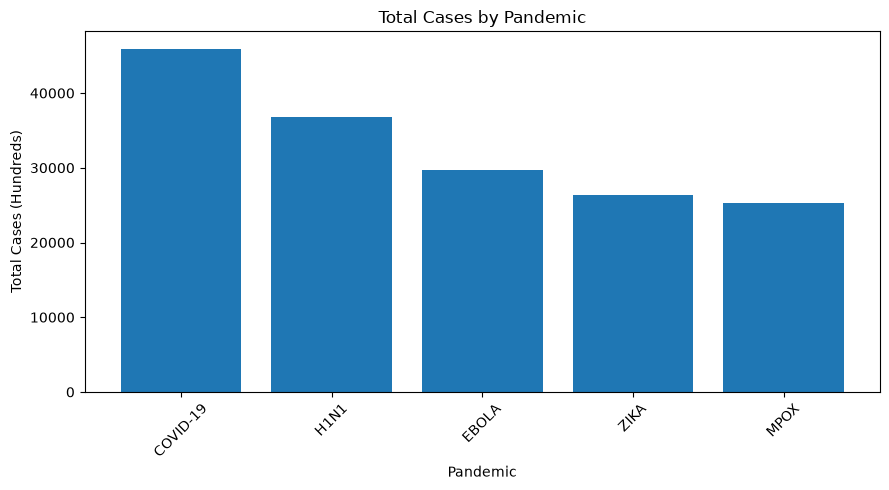

In [13]:
# Q2: Pandemic-wise Comparative Analysis

pandemic_analysis = csv.groupby("Pandemic").agg(
    Total_Cases=("Total_Cases_Hundreds", "sum"),
    Total_Deaths=("Total_Deaths_Hundreds", "sum"),
    Total_Recovered=("Recovered_Hundreds", "sum"),
)

# Sort by total cases in descending order
pandemic_analysis = pandemic_analysis.sort_values(by="Total_Cases", ascending=False)

# Display the result
print("PANDEMIC-WISE COMPARATIVE ANALYSIS")
print("-----------------------------------")
display(pandemic_analysis)

# Identify the pandemic with the highest total cases
highest_pandemic = pandemic_analysis["Total_Cases"].idxmax()
highest_cases = pandemic_analysis["Total_Cases"].max()

print("\nPandemic with the highest total case count:", highest_pandemic)
print("Highest total cases:", highest_cases)

# Bar chart
plt.figure(figsize=(9, 5))

plt.bar(pandemic_analysis.index, pandemic_analysis["Total_Cases"])

plt.xlabel("Pandemic")
plt.ylabel("Total Cases (Hundreds)")
plt.title("Total Cases by Pandemic")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TOP 10 COUNTRIES BY CASE BURDEN
--------------------------------


,Total_Cases,Average_Peak_Daily_Cases
Country,,
Usa,10824.0,217.760000
India,10512.0,200.115385
China,10060.0,218.160000
Indonesia,9510.0,191.480000
Brazil,9399.0,181.680000
Mexico,8752.0,172.080000
Japan,8551.0,166.720000
Thailand,8106.0,166.640000
Turkey,7859.0,153.120000


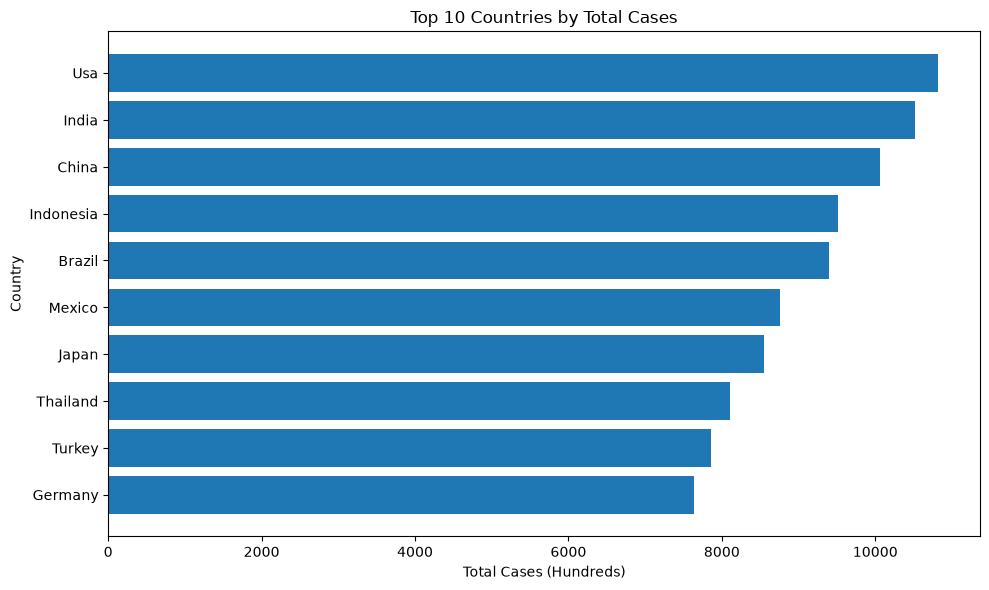

In [14]:
# Q3: Country-wise Case Burden

country_analysis = csv.groupby("Country").agg(
    Total_Cases=("Total_Cases_Hundreds", "sum"),
    Average_Peak_Daily_Cases=("Peak_Daily_Cases_Hundreds", "mean"),
)

# Sort countries by total cases in descending order
country_analysis = country_analysis.sort_values(by="Total_Cases", ascending=False)

# Select top 10 countries
top_10_countries = country_analysis.head(10)

# Display the result
print("TOP 10 COUNTRIES BY CASE BURDEN")
print("--------------------------------")
display(top_10_countries)

# Horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(top_10_countries.index, top_10_countries["Total_Cases"])

plt.xlabel("Total Cases (Hundreds)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Total Cases")

# Put highest country at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

YEAR-WISE TREND ANALYSIS
-------------------------


,Total_Cases,Total_Deaths,Total_Vaccinated
Year,,,
2009,6914.0,956,6227.0
2010,7125.0,965,7127.0
2011,7152.0,985,7952.0
2012,7685.0,1006,8855.0
2013,7950.0,1028,9761.0
2014,5471.0,859,6245.0
2015,10572.0,1686,13325.0
2016,11059.0,1714,15050.0
2017,11465.0,1753,16779.0


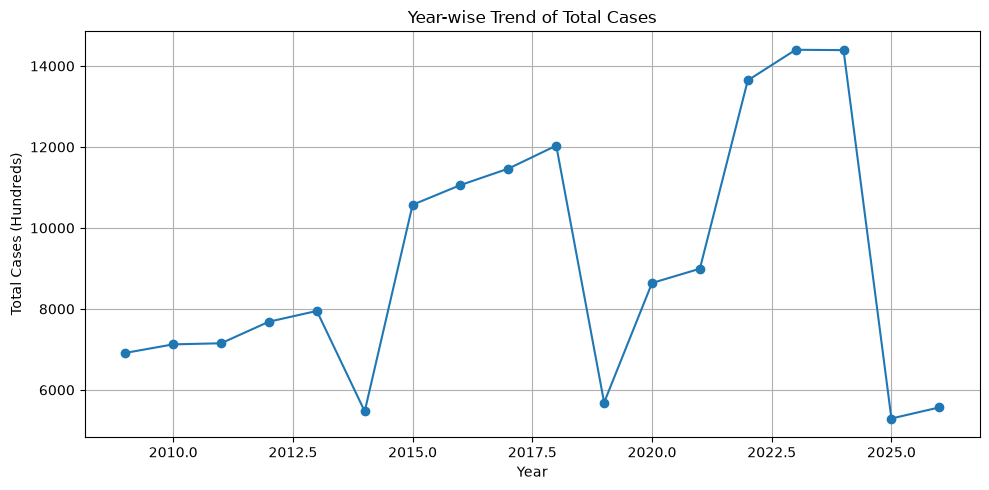

In [15]:
# Q4: Year-wise Trend Analysis

year_analysis = csv.groupby("Year").agg(
    Total_Cases=("Total_Cases_Hundreds", "sum"),
    Total_Deaths=("Total_Deaths_Hundreds", "sum"),
    Total_Vaccinated=("Vaccinated_Hundreds", "sum"),
)

# Sort by year
year_analysis = year_analysis.sort_index()

# Display the yearly analysis
print("YEAR-WISE TREND ANALYSIS")
print("-------------------------")
display(year_analysis)

# Line chart for total cases
plt.figure(figsize=(10, 5))

plt.plot(year_analysis.index, year_analysis["Total_Cases"], marker="o")

plt.xlabel("Year")
plt.ylabel("Total Cases (Hundreds)")
plt.title("Year-wise Trend of Total Cases")

plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Q5: Pandemic and Country Filtering

filtered_data = csv[
    (csv["Pandemic"] == "COVID-19") & (csv["Country"].isin(["India", "Brazil", "Usa"]))
].copy()

# Calculate required values
country_covid = filtered_data.groupby("Country").agg(
    Total_Cases=("Total_Cases_Hundreds", "sum"),
    Total_Deaths=("Total_Deaths_Hundreds", "sum"),
    Average_Vaccination_Rate=("Vaccination_Rate", "mean"),
)

# Sort by total cases in descending order
country_covid = country_covid.sort_values(by="Total_Cases", ascending=False)

# Display result
print("COVID-19 ANALYSIS: INDIA, BRAZIL AND USA")
print("-----------------------------------------")
display(country_covid)

COVID-19 ANALYSIS: INDIA, BRAZIL AND USA
-----------------------------------------


,Total_Cases,Total_Deaths,Average_Vaccination_Rate
Country,,,
Usa,3200.0,299,72.82
India,3093.0,348,72.38
Brazil,2653.0,333,69.46


VACCINATION AND CASE RELATIONSHIP
----------------------------------


,Average_Total_Cases,Average_Vaccination_Rate
Country,,
Argentina,303.750000,77.841667
Australia,281.880000,93.040000
Brazil,375.960000,70.304000
Canada,292.400000,92.768000
China,402.400000,72.860000
Egypt,295.600000,77.172000
France,300.120000,91.752000
Germany,305.280000,91.060000
India,404.307692,71.023077


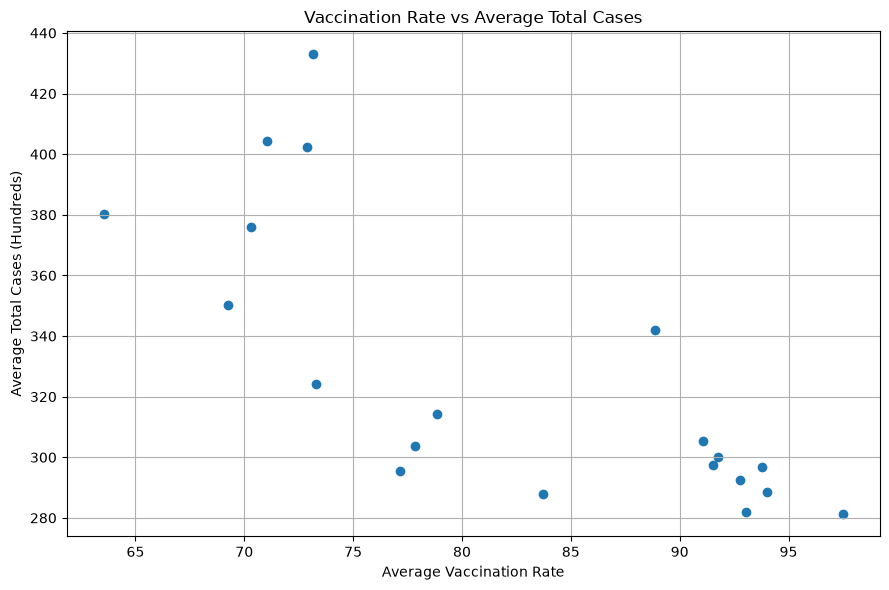

In [17]:
# Q6: Vaccination and Case Relationship

vaccination_analysis = csv.groupby("Country").agg(
    Average_Total_Cases=("Total_Cases_Hundreds", "mean"),
    Average_Vaccination_Rate=("Vaccination_Rate", "mean"),
)

# Display the result
print("VACCINATION AND CASE RELATIONSHIP")
print("----------------------------------")
display(vaccination_analysis)

# Scatter plot
plt.figure(figsize=(9, 6))

plt.scatter(
    vaccination_analysis["Average_Vaccination_Rate"],
    vaccination_analysis["Average_Total_Cases"],
)

plt.xlabel("Average Vaccination Rate")
plt.ylabel("Average Total Cases (Hundreds)")
plt.title("Vaccination Rate vs Average Total Cases")

plt.grid(True)
plt.tight_layout()
plt.show()

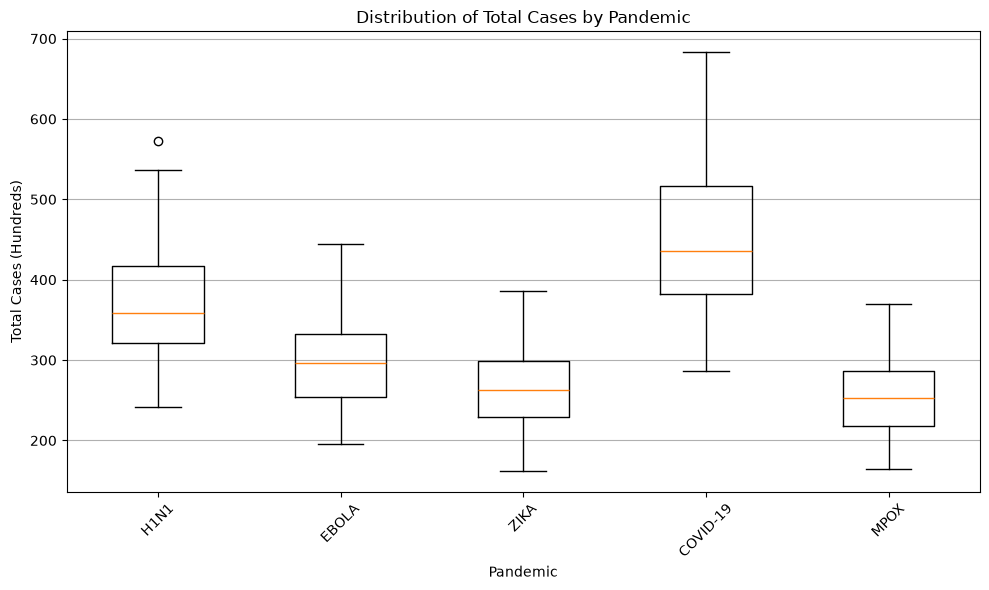

In [18]:
# Q7: Distribution of Total Cases by Pandemic

pandemics = csv["Pandemic"].unique()

boxplot_data = []

for pandemic in pandemics:
    values = csv[csv["Pandemic"] == pandemic]["Total_Cases_Hundreds"]
    boxplot_data.append(values)

plt.figure(figsize=(10, 6))

plt.boxplot(boxplot_data, tick_labels=pandemics)

plt.xlabel("Pandemic")
plt.ylabel("Total Cases (Hundreds)")
plt.title("Distribution of Total Cases by Pandemic")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

HEALTHCARE CAPACITY BY CONTINENT
---------------------------------


,Average_Hospital_Beds,Average_Healthcare_Workers,Average_Total_Cases
Continent,,,
Africa,405.500000,357.000000,291.740000
Asia,548.971429,489.428571,350.085714
Europe,520.240000,467.200000,297.616000
North America,556.533333,490.000000,358.480000
Oceania,459.200000,393.000000,281.880000
South America,478.200000,417.500000,341.160000


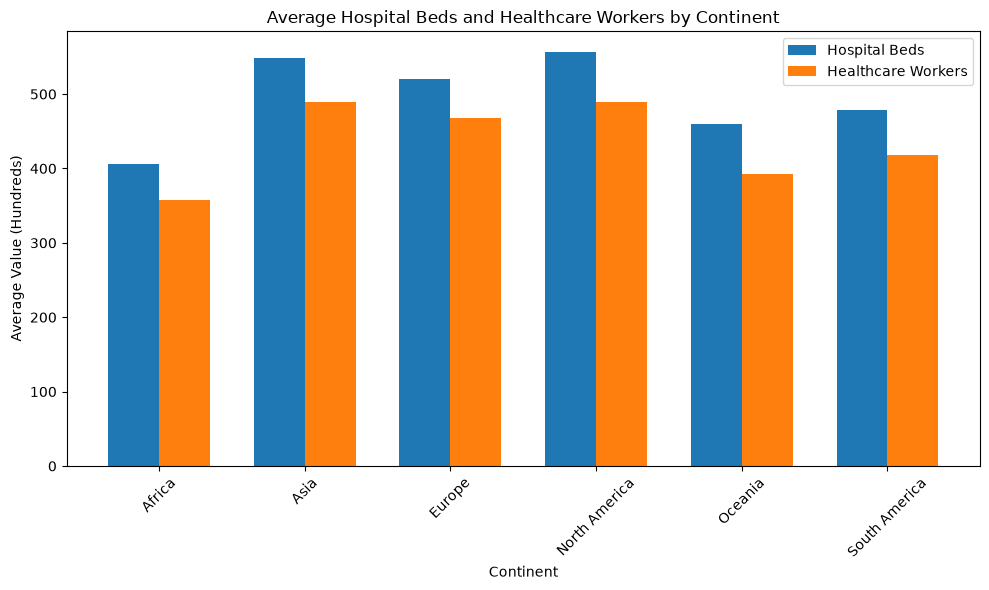

In [19]:
# Q8: Healthcare Capacity Analysis

continent_analysis = csv.groupby("Continent").agg(
    Average_Hospital_Beds=("Hospital_Beds_Hundreds", "mean"),
    Average_Healthcare_Workers=("Healthcare_Workers_Hundreds", "mean"),
    Average_Total_Cases=("Total_Cases_Hundreds", "mean"),
)

print("HEALTHCARE CAPACITY BY CONTINENT")
print("---------------------------------")
display(continent_analysis)

# Grouped bar chart
x = np.arange(len(continent_analysis))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    continent_analysis["Average_Hospital_Beds"],
    width,
    label="Hospital Beds",
)

plt.bar(
    x + width / 2,
    continent_analysis["Average_Healthcare_Workers"],
    width,
    label="Healthcare Workers",
)

plt.xlabel("Continent")
plt.ylabel("Average Value (Hundreds)")
plt.title("Average Hospital Beds and Healthcare Workers by Continent")

plt.xticks(x, continent_analysis.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

CORRELATION MATRIX
------------------


,Total_Cases_Hundreds,Total_Deaths_Hundreds,Recovered_Hundreds,Vaccinated_Hundreds,Tests_Hundreds,Peak_Daily_Cases_Hundreds
Total_Cases_Hundreds,1.000000,0.904752,0.961045,0.408000,0.957358,0.843979
Total_Deaths_Hundreds,0.904752,1.000000,0.892236,0.392682,0.890747,0.786082
Recovered_Hundreds,0.961045,0.892236,1.000000,0.408563,0.945550,0.827527
Vaccinated_Hundreds,0.408000,0.392682,0.408563,1.000000,0.411298,0.397788
Tests_Hundreds,0.957358,0.890747,0.945550,0.411298,1.000000,0.836053
Peak_Daily_Cases_Hundreds,0.843979,0.786082,0.827527,0.397788,0.836053,1.000000


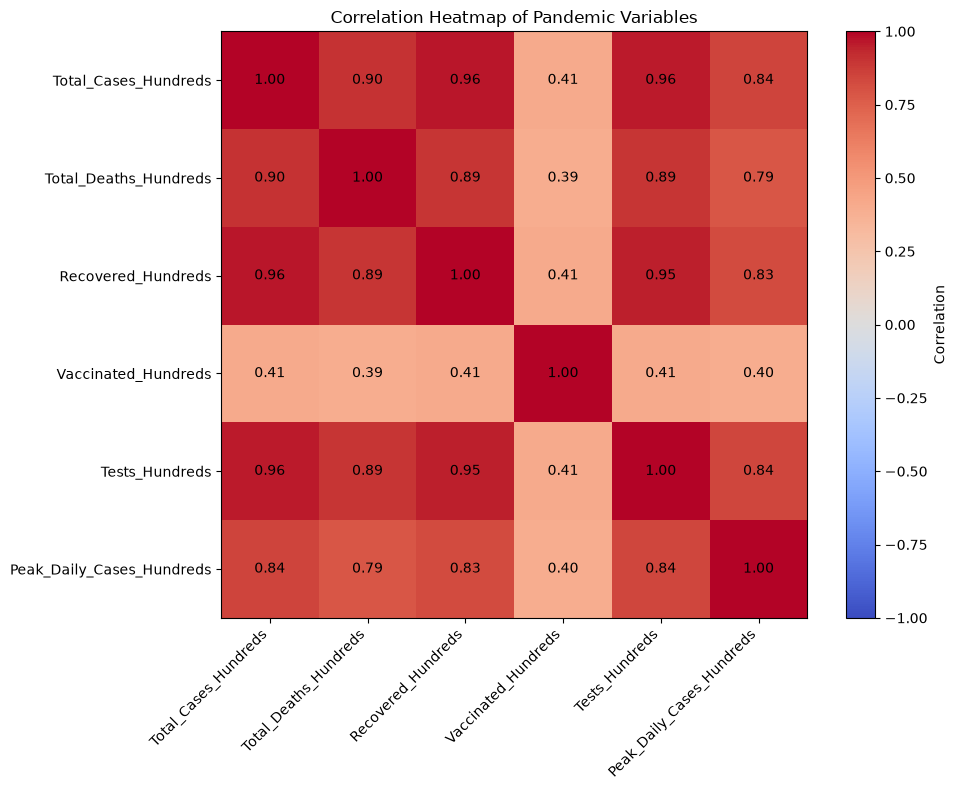

In [20]:
# Q9: Correlation Analysis

correlation_columns = [
    "Total_Cases_Hundreds",
    "Total_Deaths_Hundreds",
    "Recovered_Hundreds",
    "Vaccinated_Hundreds",
    "Tests_Hundreds",
    "Peak_Daily_Cases_Hundreds",
]

correlation_matrix = csv[correlation_columns].corr()

print("CORRELATION MATRIX")
print("------------------")
display(correlation_matrix)

# Create heatmap
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)), correlation_columns, rotation=45, ha="right"
)

plt.yticks(range(len(correlation_columns)), correlation_columns)

# Display numerical correlation values
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap of Pandemic Variables")
plt.tight_layout()
plt.show()

MULTI-DIMENSIONAL PANDEMIC SUMMARY
----------------------------------


,Total_Cases,Total_Deaths,Average_Vaccination_Rate,Maximum_Peak_Daily_Cases
Pandemic,,,,
COVID-19,45964.0,5558,81.855446,436
H1N1,36826.0,4940,82.136000,341
EBOLA,29704.0,4441,82.469000,273
ZIKA,26299.0,4192,82.480808,246
MPOX,25252.0,4137,82.335000,235


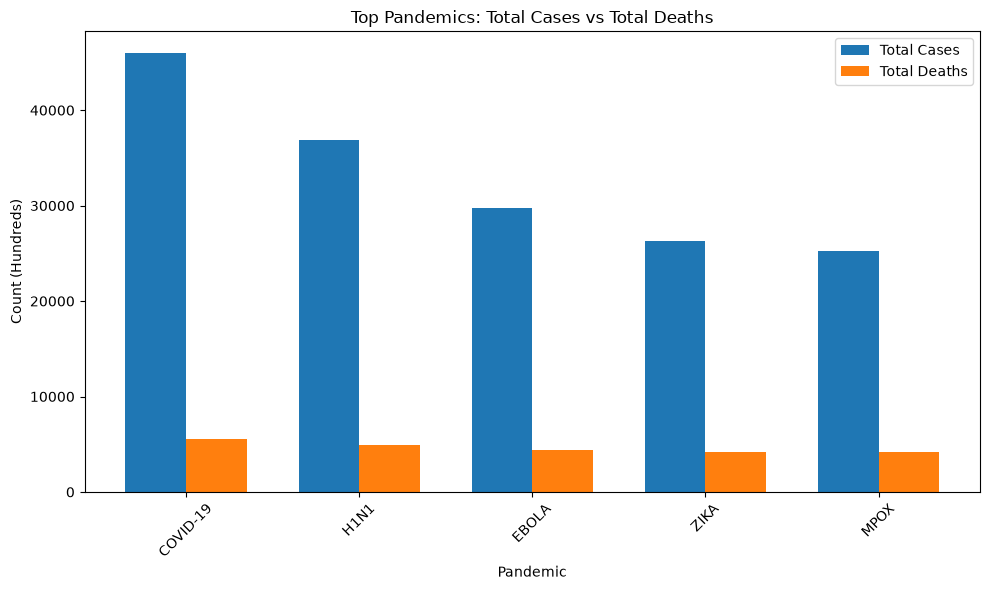

In [21]:
# Q10: Multi-dimensional Pandemic Summary

pandemic_summary = csv.groupby("Pandemic").agg(
    Total_Cases=("Total_Cases_Hundreds", "sum"),
    Total_Deaths=("Total_Deaths_Hundreds", "sum"),
    Average_Vaccination_Rate=("Vaccination_Rate", "mean"),
    Maximum_Peak_Daily_Cases=("Peak_Daily_Cases_Hundreds", "max"),
)

# Sort by total cases
pandemic_summary = pandemic_summary.sort_values(by="Total_Cases", ascending=False)

print("MULTI-DIMENSIONAL PANDEMIC SUMMARY")
print("----------------------------------")
display(pandemic_summary)

# Filter top 5 pandemics by total cases
top_pandemics = pandemic_summary.head(5)

# Visualization
x = np.arange(len(top_pandemics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width / 2, top_pandemics["Total_Cases"], width, label="Total Cases")

plt.bar(x + width / 2, top_pandemics["Total_Deaths"], width, label="Total Deaths")

plt.xlabel("Pandemic")
plt.ylabel("Count (Hundreds)")
plt.title("Top Pandemics: Total Cases vs Total Deaths")

plt.xticks(x, top_pandemics.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()